# Project: Analyze A/B Test Results

## Introduction

This project analyzes the results of a marketing A/B test to evaluate whether showing advertisements increases user conversion compared with showing Public Service Announcements (PSAs).
Users were divided into two experimental groups:

1. Treatment Group (ad): Users were shown advertisements.
2. Control Group (psa): Users were shown Public Service Announcements instead of advertisements.

The primary objective is to determine whether advertising leads to a statistically significant improvement in conversion rate.

## Business Question
Does showing advertisements increase the user conversion rate compared with showing PSAs?
The analysis also explores whether advertising performance varies by:
1. Number of ad exposures
2. Day of the week
3. Hour of the day

## Dataset
The project dataset from Kaggle. Key features include:              
user id，test group，converted，total ads, most ads day, most ads hour	   

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [21]:
df = pd.read_csv("marketing_AB.csv")
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [22]:
df.shape

(588101, 7)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [24]:
df.isnull().sum()

,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [25]:
df["user id"].duplicated().sum()

np.int64(0)

In [26]:
df["test group"].value_counts()

,count
test group,
ad,564577
psa,23524


In [27]:
df["converted"].value_counts()

,count
converted,
False,573258
True,14843


In [28]:
df["most ads day"].value_counts()

,count
most ads day,
Friday,92608
Monday,87073
Sunday,85391
Thursday,82982
Saturday,81660
Wednesday,80908
Tuesday,77479


## Metrics
**calculate the conversion rate for each group**

In [29]:
ad_group=df[df["test group"]=='ad']
ad_conversion=ad_group['converted']
ad_conversion_rate=ad_conversion.mean()
print(f"Conversion rate for Group ad:{ad_conversion_rate*100:.2f}%")

Conversion rate for Group ad:2.55%


In [30]:
psa_group=df[df["test group"]=='psa']
psa_conversion=psa_group['converted']
psa_conversion_rate=psa_conversion.mean()
print(f"Conversion rate for Group psa:{psa_conversion_rate*100:.2f}%")

Conversion rate for Group psa:1.79%


## Put your answer here
**Based on the finding above**

The ad group achieved a 2.55% conversion rate compared with 1.79% for the PSA group, representing a 0.77 percentage-point absolute increase and approximately a 43.1% relative lift. However, we still need to conduct a statistical significance test to determine whether this observed difference is statistically significant.

## A/B Test
### 1.Hypothesis

H₀ (Null Hypothesis): The conversion rate of the ad group is equal to the conversion rate of the PSA group. $H_0: p_{ad} = p_{psa}$

H₁ (Alternative Hypothesis): The conversion rate of the ad group is different from the conversion rate of the PSA group. $H_1: p_{ad} \neq p_{psa}$

Significance level: α = 0.05


### 2.Calculate the number of conversions and the sample size for each group.

In [32]:
ad_conversions = ad_group["converted"].sum()
ad_total = len(ad_group)

psa_conversions = psa_group["converted"].sum()
psa_total = len(psa_group)

print("Ad conversions:", ad_conversions)
print("Ad total:", ad_total)
print("PSA conversions:", psa_conversions)
print("PSA total:", psa_total)

Ad conversions: 14423
Ad total: 564577
PSA conversions: 420
PSA total: 23524


###3.Statistical Significance Test: Two-Proportion Z-Test
**Why use a two-proportion z-test?**

A two-proportion z-test is appropriate because the outcome variable, converted, is binary, and we want to compare the conversion rates between two independent groups: the ad group and the PSA group. Since the sample sizes are large, the normal approximation is appropriate.

The project used **the number of conversions** and **total users in each group** as inputs, then compared the p-value with a significance level of 0.05. If the p-value was below 0.05, I rejected the null hypothesis and concluded that the difference in conversion rates was statistically significant.

In [35]:
from statsmodels.stats.proportion import proportions_ztest

count = [ad_conversions, psa_conversions] #Number of users who converted
nob = [ad_total, psa_total] #number of observations

z_stat, p_value = proportions_ztest(count, nobs)

print(count)
print(nob)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("The difference in conversion rates is not statistically significant.")

[np.int64(14423), np.int64(420)]
[564577, 23524]
Z-statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13
Reject the null hypothesis.
The difference in conversion rates is statistically significant.


**Results:** The p-value (1.71 × 10⁻¹³) is far below the significance level of 0.05. Therefore, we reject the null hypothesis and conclude that the difference in conversion rates between the ad and PSA groups is statistically significant.

The ad group achieved a higher conversion rate (2.55%) than the PSA group (1.79%), suggesting that advertising had a positive effect on conversion.

##Data Visualization

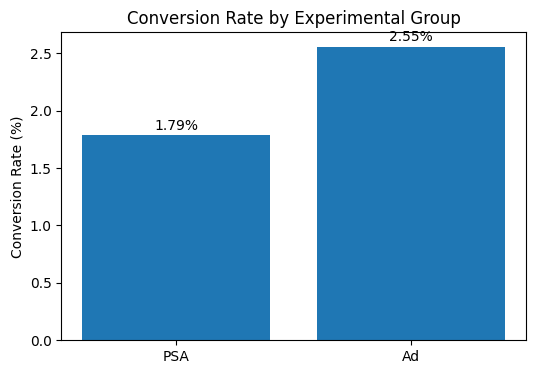

In [36]:
import matplotlib.pyplot as plt

groups = ['PSA', 'Ad']
conversion_rates = [psa_conversion_rate * 100, ad_conversion_rate * 100]

plt.figure(figsize=(6, 4))
plt.bar(groups, conversion_rates)

plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Experimental Group')

for i, value in enumerate(conversion_rates):
    plt.text(i, value + 0.05, f'{value:.2f}%', ha='center')

plt.show()

##Conclusion
The A/B test provides strong evidence that advertising had a positive effect on user conversion. The ad group achieved a **2.55% conversion rate**, compared with **1.79% for the PSA control grou**p, representing an absolute increase of approximately **0.77 percentage points** and a **43.1% relative lift**.

The two-proportion **z-test produced a z-statistic of 7.37 **and **a p-value of approximately 1.71 × 10⁻¹³**, which is far below the 0.05 significance level. Therefore, we **reject the null hypothesis** and conclude that the difference in conversion rates between the two groups is statistically significant.

From a business perspective, the results suggest that the advertising campaign was effective at increasing conversions compared with the PSA control condition. However, before recommending a full-scale rollout, I would also evaluate the **incremental number of conversions, campaign costs, and return on investment (ROI) **to determine whether the statistically significant improvement also delivers meaningful business value.